In [2]:
# Data Analysis
import numpy as np
import pandas as pd
import random as rnd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
# from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Misc.
from sklearn.preprocessing import LabelEncoder
from imblearn.combine import SMOTETomek
from collections import Counter
import category_encoders as ce

In [4]:
# Import Data
data = pd.read_csv("predictive_maintenance.csv")

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [8]:
data.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


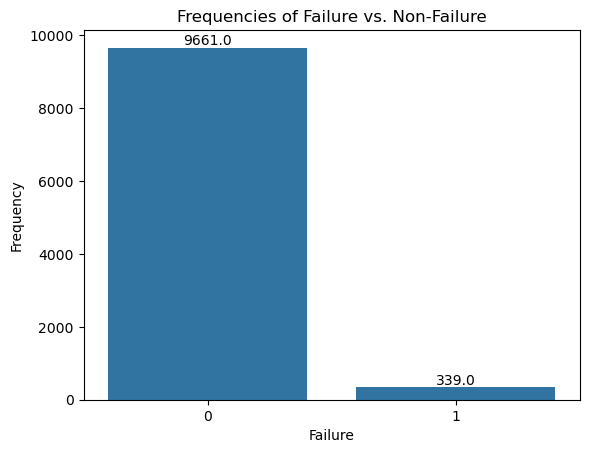

In [9]:
# Create a bar graph of No. of Failures vs Non-Failures
sns.countplot(x='Target', data=data)
plt.xlabel('Failure')
plt.ylabel('Frequency')
plt.title('Frequencies of Failure vs. Non-Failure')

# Add count annotations above each bar
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()

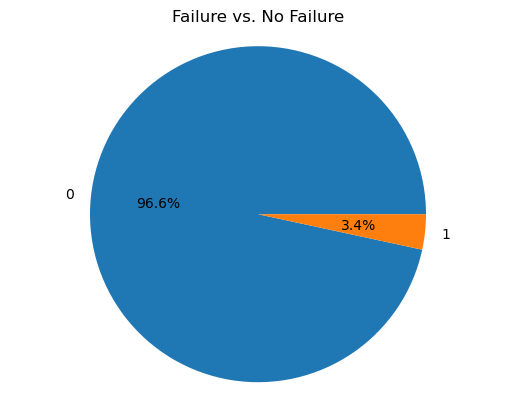

In [10]:
# Create a pie chart of Failures vs No Failures
category_counts = data['Target'].value_counts()

plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%')
plt.axis('equal')
plt.title('Failure vs. No Failure')
plt.show()

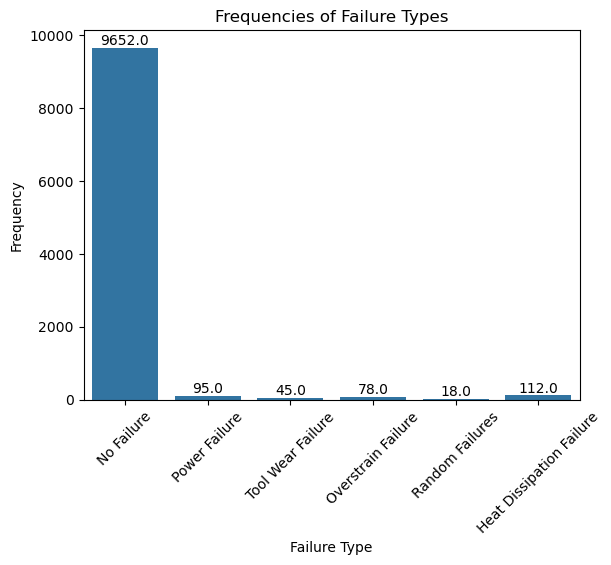

In [11]:
sns.countplot(x='Failure Type', data=data)
plt.xlabel('Failure Type')
plt.ylabel('Frequency')
plt.title('Frequencies of Failure Types')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add count annotations above each bar
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()

In [12]:
# Drop ID & UID since they provide no information
data.drop(data.columns[0:2], axis=1, inplace=True)
data.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M,298.1,308.6,1551,42.8,0,0,No Failure
1,L,298.2,308.7,1408,46.3,3,0,No Failure
2,L,298.1,308.5,1498,49.4,5,0,No Failure
3,L,298.2,308.6,1433,39.5,7,0,No Failure
4,L,298.2,308.7,1408,40.0,9,0,No Failure


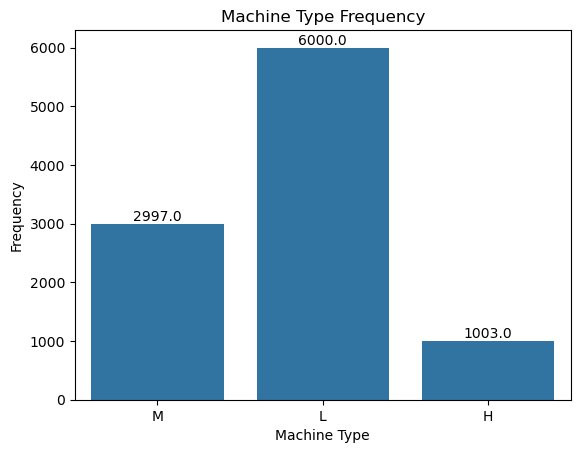

In [13]:
# Create Bar Graph of Machine Type Frequency
sns.countplot(x='Type', data=data)
plt.xlabel('Machine Type')
plt.ylabel('Frequency')
plt.title('Machine Type Frequency')

# Add count annotations above each bar
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()

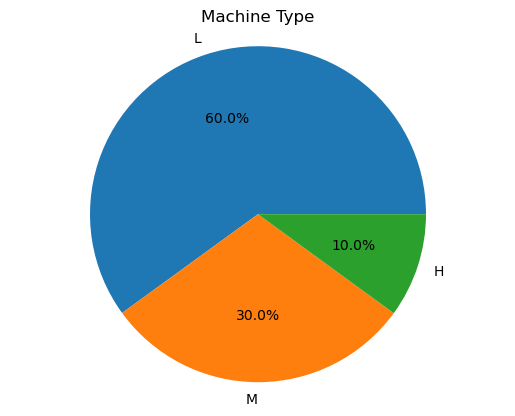

In [14]:
# Create Pie Chart of Machine Type Frequency
category_counts = data['Type'].value_counts()

plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%')
plt.axis('equal')
plt.title('Machine Type')
plt.show()

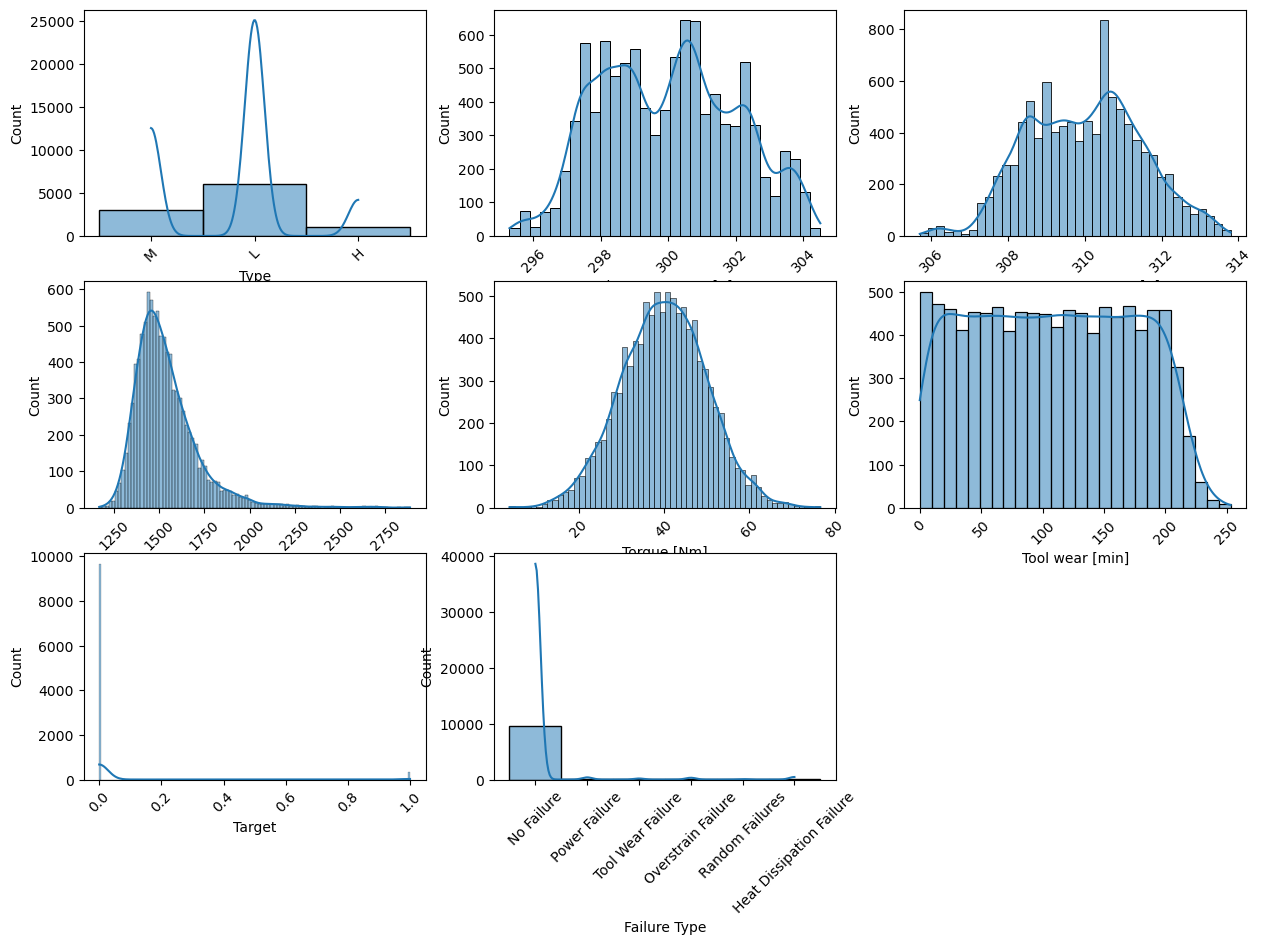

In [15]:
plt.figure(figsize=(15,10))
for i,col in enumerate(data.columns,1):
    plt.subplot(3,3,i)
    sns.histplot(data[col],kde=True)
    plt.xticks(rotation=45)

In [ ]:
# Ordinal-encode the categorical 'Type' column (L→1, M→2, H→3)
# NOTE: We do NOT encode 'Failure Type' anymore — we use binary 'Target' as our label
encoder = ce.OrdinalEncoder(cols=['Type'])
data = encoder.fit_transform(data)
data.head()

In [ ]:
# Verify class balance of binary target
print('Class distribution (Target):')
print(data['Target'].value_counts())
print(f"\nDefect rate: {data['Target'].mean()*100:.2f}%")

In [ ]:
# Define features and binary target
# Dropping 'Failure Type' (multiclass detail not needed for binary prediction)
# Dropping 'Target' from X — it was previously leaking the answer into features!
X = data.drop(columns=['Failure Type', 'Target'], axis=1)
y = data['Target'].values  # binary: 0 = Normal, 1 = Defect

print('Features used for training:', X.columns.tolist())
print('X shape:', X.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

In [ ]:
# All features are now numeric — no additional encoding needed
# Type is already ordinal-encoded (L=1, M=2, H=3) in cell 13
print('Feature dtypes:')
print(X_train.dtypes)

In [ ]:
# Apply SMOTETomek on training set only to handle class imbalance
# We only resample X_train — NOT the full dataset — to avoid data leakage
smk = SMOTETomek(random_state=42)
X_res, y_res = smk.fit_resample(X_train, y_train)
print(f'Before SMOTE: {Counter(y_train)}')
print(f'After  SMOTE: {Counter(y_res)}')
print(f'Resampled shape: {X_res.shape}')

In [ ]:
# Confirm resampling result
print(f'Original training set: {Counter(y_train)}')
print(f'Resampled training set: {Counter(y_res)}')

In [ ]:
# VERIFIED FIXED VERSION
print('>>> RUNNING UPDATED CORRELATION CODE <<<')
plt.figure(figsize=(15, 10))
# Filter out any non-numeric columns (like 'Failure Type')
df_numeric = data.select_dtypes(include='number')
sns.heatmap(data=df_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Logistic Regression (trained on SMOTE-resampled data)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_res, y_res)
y_pred_lr = logreg.predict(X_test)

log_train    = round(logreg.score(X_res, y_res) * 100, 2)
log_accuracy = round(accuracy_score(y_pred_lr, y_test) * 100, 2)

print('Training Accuracy    :', log_train, '%')
print('Model Accuracy Score :', log_accuracy, '%')
print('\033[1m' + '-'*56 + '\033[0m')
print('Logistic Regression Classification Report:')
print(classification_report(y_test, y_pred_lr))
print('\033[1m' + '-'*56 + '\033[0m')

In [ ]:
# Support Vector Machine (trained on SMOTE-resampled data)
svc = SVC()
svc.fit(X_res, y_res)
y_pred_svc = svc.predict(X_test)

svc_train    = round(svc.score(X_res, y_res) * 100, 2)
svc_accuracy = round(accuracy_score(y_pred_svc, y_test) * 100, 2)

print('Training Accuracy    :', svc_train, '%')
print('Model Accuracy Score :', svc_accuracy, '%')
print('\033[1m' + '-'*56 + '\033[0m')
print('SVC Classification Report:')
print(classification_report(y_test, y_pred_svc))
print('\033[1m' + '-'*56 + '\033[0m')

In [ ]:
# Random Forest Classifier (trained on SMOTE-resampled data)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_res, y_res)
y_pred_rf = random_forest.predict(X_test)

random_forest_train    = round(random_forest.score(X_res, y_res) * 100, 2)
random_forest_accuracy = round(accuracy_score(y_pred_rf, y_test) * 100, 2)

print('Training Accuracy    :', random_forest_train, '%')
print('Model Accuracy Score :', random_forest_accuracy, '%')
print('\033[1m' + '-'*56 + '\033[0m')
print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred_rf))
print('\033[1m' + '-'*56 + '\033[0m')

# Feature importance
feat_imp = pd.Series(random_forest.feature_importances_, index=X.columns).sort_values(ascending=False)
print('\nFeature Importances:')
print(feat_imp.round(3))

In [ ]:
import pickle

# Save the corrected Random Forest model
# Features: ['Type', 'Air temperature [K]', 'Process temperature [K]',
#            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
# Target: binary 0=Normal, 1=Defect
with open('model.pkl', 'wb') as file:
    pickle.dump(random_forest, file)

print('model.pkl saved successfully!')
print(f'Features ({random_forest.n_features_in_}):', list(random_forest.feature_names_in_))

In [ ]:
# Preview the final processed dataset
data.head(10)

In [ ]:
# Preview known defect rows (Target == 1)
data[data['Target'] == 1].head(10)